In [107]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import os
from skimage.io import imread
from skimage.transform import resize
from skimage.color import rgb2lab, rgb2gray
from skimage.filters import threshold_otsu, sobel, gaussian, unsharp_mask
from skimage.morphology import binary_opening, binary_closing, square, diamond, footprint_rectangle, disk
from skimage.feature import hog

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Working with Images: Exercise
## Segmentation, feature extraction, computations, deep dive into deep learning :)

In this exercise, you'll be working with the [FruitSeg30](https://data.mendeley.com/datasets/vkht8pfsp3/3) dataset. Open the link, download the files, and explore them a little before starting. The main questions we'll look at revolve around segmentation (separating fruits from background), measurements, transformations, and similarities (also called retrieval).

### Problem 1. Load and inspect the dataset
Load the data and show some statistics. Note any peculiarities, interesting things. A very important point is that you will likely NOT be able to load the entire dataset in memory, all at once. And you shouldn't! :) Even if you could, most modern datasets are in the order of terabytes. You'll need to find ways of preprocessing the data in parts.

Think about image statistics, distributions across classes, features, etc. Consider the masks too, if possible. You could even create some measurements. 

**Hint:** Follow the process you already know for data processing and EDA; the only difference is that you don't have a table (yet).

**Hint 2:** Try to think about normal behavior and anomalies / outliers.

In [108]:
os.listdir('data/')

['Apple_Gala',
 'Apple_Golden Delicious',
 'Avocado',
 'Banana',
 'Berry',
 'Burmese Grape',
 'Carambola',
 'Date Palm',
 'Dragon',
 'Elephant Apple',
 'Grape',
 'Green Coconut',
 'Guava',
 'Hog Plum',
 'Kiwi',
 'Lichi',
 'Malta',
 'Mango Golden Queen',
 'Mango_Alphonso',
 'Mango_Amrapali',
 'Mango_Bari',
 'Mango_Himsagar',
 'Olive',
 'Orange',
 'Palm',
 'Persimmon',
 'Pineapple',
 'Pomegranate',
 'Watermelon',
 'White Pear']

In [109]:
fruit_classes = os.listdir('data/')

In [110]:
for fruit_class in fruit_classes:
    print(fruit_class)
    print(os.listdir(f'data/{fruit_class}/Images'))

Apple_Gala
['1.jpg', '10.jpg', '11.jpg', '12.jpg', '13.jpg', '14.jpg', '15.jpg', '16.jpg', '17.jpg', '18.jpg', '19.jpg', '2.jpg', '20.jpg', '21.jpg', '22.jpg', '23.jpg', '24.jpg', '25.jpg', '26.jpg', '27.jpg', '28.jpg', '29.jpg', '3.jpg', '30.jpg', '31.jpg', '32.jpg', '33.jpg', '34.jpg', '35.jpg', '36.jpg', '37.jpg', '38.jpg', '39.jpg', '4.jpg', '40.jpg', '41.jpg', '42.jpg', '43.jpg', '44.jpg', '45.jpg', '46.jpg', '47.jpg', '48.jpg', '49.jpg', '5.jpg', '50.jpg', '51.jpg', '52.jpg', '53.jpg', '54.jpg', '55.jpg', '56.jpg', '57.jpg', '58.jpg', '59.jpg', '6.jpg', '60.jpg', '61.jpg', '62.jpg', '63.jpg', '64.jpg', '65.jpg', '7.jpg', '8.jpg', '9.jpg']
Apple_Golden Delicious
['1.jpg', '10.jpg', '11.jpg', '12.jpg', '13.jpg', '14.jpg', '15.jpg', '16.jpg', '17.jpg', '18.jpg', '19.jpg', '2.jpg', '20.jpg', '21.jpg', '22.jpg', '23.jpg', '24.jpg', '25.jpg', '26.jpg', '27.jpg', '28.jpg', '29.jpg', '3.jpg', '30.jpg', '31.jpg', '32.jpg', '33.jpg', '34.jpg', '35.jpg', '36.jpg', '37.jpg', '38.jpg', '39.jp

In [111]:
for fruit_class in fruit_classes:
    print(fruit_class, end=': ')
    print(len(os.listdir(f'data/{fruit_class}/Images')))

Apple_Gala: 65
Apple_Golden Delicious: 57
Avocado: 72
Banana: 82
Berry: 62
Burmese Grape: 78
Carambola: 100
Date Palm: 147
Dragon: 96
Elephant Apple: 81
Grape: 82
Green Coconut: 37
Guava: 55
Hog Plum: 91
Kiwi: 61
Lichi: 48
Malta: 50
Mango Golden Queen: 16
Mango_Alphonso: 45
Mango_Amrapali: 67
Mango_Bari: 57
Mango_Himsagar: 85
Olive: 51
Orange: 83
Palm: 59
Persimmon: 33
Pineapple: 65
Pomegranate: 61
Watermelon: 42
White Pear: 41


In [112]:
number_of_images = {"name": [], "number": []}
for fruit_class in fruit_classes:
    print(fruit_class, end=': ')
    num = len(os.listdir(f'data/{fruit_class}/Images'))
    print(num)
    number_of_images["name"].append(fruit_class)
    number_of_images["number"].append(num)

Apple_Gala: 65
Apple_Golden Delicious: 57
Avocado: 72
Banana: 82
Berry: 62
Burmese Grape: 78
Carambola: 100
Date Palm: 147
Dragon: 96
Elephant Apple: 81
Grape: 82
Green Coconut: 37
Guava: 55
Hog Plum: 91
Kiwi: 61
Lichi: 48
Malta: 50
Mango Golden Queen: 16
Mango_Alphonso: 45
Mango_Amrapali: 67
Mango_Bari: 57
Mango_Himsagar: 85
Olive: 51
Orange: 83
Palm: 59
Persimmon: 33
Pineapple: 65
Pomegranate: 61
Watermelon: 42
White Pear: 41


In [113]:
number_of_images

{'name': ['Apple_Gala',
  'Apple_Golden Delicious',
  'Avocado',
  'Banana',
  'Berry',
  'Burmese Grape',
  'Carambola',
  'Date Palm',
  'Dragon',
  'Elephant Apple',
  'Grape',
  'Green Coconut',
  'Guava',
  'Hog Plum',
  'Kiwi',
  'Lichi',
  'Malta',
  'Mango Golden Queen',
  'Mango_Alphonso',
  'Mango_Amrapali',
  'Mango_Bari',
  'Mango_Himsagar',
  'Olive',
  'Orange',
  'Palm',
  'Persimmon',
  'Pineapple',
  'Pomegranate',
  'Watermelon',
  'White Pear'],
 'number': [65,
  57,
  72,
  82,
  62,
  78,
  100,
  147,
  96,
  81,
  82,
  37,
  55,
  91,
  61,
  48,
  50,
  16,
  45,
  67,
  57,
  85,
  51,
  83,
  59,
  33,
  65,
  61,
  42,
  41]}

In [114]:
number_of_images = pd.DataFrame(number_of_images)

In [115]:
number_of_images.sort_values("number", ascending=True)

,name,number
17,Mango Golden Queen,16
25,Persimmon,33
11,Green Coconut,37
29,White Pear,41
28,Watermelon,42
18,Mango_Alphonso,45
15,Lichi,48
16,Malta,50
22,Olive,51
12,Guava,55


In [116]:
sample_classes = number_of_images[
    (number_of_images.number >= 60) & 
    (number_of_images.number <= 80)
    ].sample(5, random_state=123123)

In [117]:
sample_classes

,name,number
26,Pineapple,65
19,Mango_Amrapali,67
4,Berry,62
0,Apple_Gala,65
14,Kiwi,61


In [118]:
number_of_images = {"name": [], "number": [], "path": []}
for fruit_class in fruit_classes:
    print(fruit_class, end=': ')
    num = len(os.listdir(f'data/{fruit_class}/Images'))
    print(num)
    number_of_images["name"].append(fruit_class)
    number_of_images["path"] = f"data/{fruit_class}/Images"
    number_of_images["number"].append(num)
    

Apple_Gala: 65
Apple_Golden Delicious: 57
Avocado: 72
Banana: 82
Berry: 62
Burmese Grape: 78
Carambola: 100
Date Palm: 147
Dragon: 96
Elephant Apple: 81
Grape: 82
Green Coconut: 37
Guava: 55
Hog Plum: 91
Kiwi: 61
Lichi: 48
Malta: 50
Mango Golden Queen: 16
Mango_Alphonso: 45
Mango_Amrapali: 67
Mango_Bari: 57
Mango_Himsagar: 85
Olive: 51
Orange: 83
Palm: 59
Persimmon: 33
Pineapple: 65
Pomegranate: 61
Watermelon: 42
White Pear: 41


In [119]:
number_of_images = pd.DataFrame(number_of_images)

In [120]:
number_of_images.sort_values("number", ascending=True)

,name,number,path
17,Mango Golden Queen,16,data/White Pear/Images
25,Persimmon,33,data/White Pear/Images
11,Green Coconut,37,data/White Pear/Images
29,White Pear,41,data/White Pear/Images
28,Watermelon,42,data/White Pear/Images
18,Mango_Alphonso,45,data/White Pear/Images
15,Lichi,48,data/White Pear/Images
16,Malta,50,data/White Pear/Images
22,Olive,51,data/White Pear/Images
12,Guava,55,data/White Pear/Images


In [121]:
sample_classes = number_of_images[
    (number_of_images.number >= 60) & 
    (number_of_images.number <= 80)
    ].sample(5, random_state=123123)

In [122]:
sample_classes

,name,number,path
26,Pineapple,65,data/White Pear/Images
19,Mango_Amrapali,67,data/White Pear/Images
4,Berry,62,data/White Pear/Images
0,Apple_Gala,65,data/White Pear/Images
14,Kiwi,61,data/White Pear/Images


In [123]:
os.listdir(sample_classes.loc[26].path)

['1.jpg',
 '10.jpg',
 '11.jpg',
 '12.jpg',
 '13.jpg',
 '14.jpg',
 '15.jpg',
 '16.jpg',
 '17.jpg',
 '18.jpg',
 '19.jpg',
 '2.jpg',
 '20.jpg',
 '21.jpg',
 '22.jpg',
 '23.jpg',
 '24.jpg',
 '25.jpg',
 '26.jpg',
 '27.jpg',
 '28.jpg',
 '29.jpg',
 '3.jpg',
 '30.jpg',
 '31.jpg',
 '32.jpg',
 '33.jpg',
 '34.jpg',
 '35.jpg',
 '36.jpg',
 '37.jpg',
 '38.jpg',
 '39.jpg',
 '4.jpg',
 '40.jpg',
 '41.jpg',
 '5.jpg',
 '6.jpg',
 '7.jpg',
 '8.jpg',
 '9.jpg']

In [124]:
for i, row in sample_classes.iterrows():
    print(os.listdir(row.path))

['1.jpg', '10.jpg', '11.jpg', '12.jpg', '13.jpg', '14.jpg', '15.jpg', '16.jpg', '17.jpg', '18.jpg', '19.jpg', '2.jpg', '20.jpg', '21.jpg', '22.jpg', '23.jpg', '24.jpg', '25.jpg', '26.jpg', '27.jpg', '28.jpg', '29.jpg', '3.jpg', '30.jpg', '31.jpg', '32.jpg', '33.jpg', '34.jpg', '35.jpg', '36.jpg', '37.jpg', '38.jpg', '39.jpg', '4.jpg', '40.jpg', '41.jpg', '5.jpg', '6.jpg', '7.jpg', '8.jpg', '9.jpg']
['1.jpg', '10.jpg', '11.jpg', '12.jpg', '13.jpg', '14.jpg', '15.jpg', '16.jpg', '17.jpg', '18.jpg', '19.jpg', '2.jpg', '20.jpg', '21.jpg', '22.jpg', '23.jpg', '24.jpg', '25.jpg', '26.jpg', '27.jpg', '28.jpg', '29.jpg', '3.jpg', '30.jpg', '31.jpg', '32.jpg', '33.jpg', '34.jpg', '35.jpg', '36.jpg', '37.jpg', '38.jpg', '39.jpg', '4.jpg', '40.jpg', '41.jpg', '5.jpg', '6.jpg', '7.jpg', '8.jpg', '9.jpg']
['1.jpg', '10.jpg', '11.jpg', '12.jpg', '13.jpg', '14.jpg', '15.jpg', '16.jpg', '17.jpg', '18.jpg', '19.jpg', '2.jpg', '20.jpg', '21.jpg', '22.jpg', '23.jpg', '24.jpg', '25.jpg', '26.jpg', '27.jpg

In [125]:
for i, row in sample_classes.iterrows():
    image_paths = os.listdir(row.path)
    for image_path in image_paths:
        full_path = f"{row.path}/{image_path}"
        print(full_path)

data/White Pear/Images/1.jpg
data/White Pear/Images/10.jpg
data/White Pear/Images/11.jpg
data/White Pear/Images/12.jpg
data/White Pear/Images/13.jpg
data/White Pear/Images/14.jpg
data/White Pear/Images/15.jpg
data/White Pear/Images/16.jpg
data/White Pear/Images/17.jpg
data/White Pear/Images/18.jpg
data/White Pear/Images/19.jpg
data/White Pear/Images/2.jpg
data/White Pear/Images/20.jpg
data/White Pear/Images/21.jpg
data/White Pear/Images/22.jpg
data/White Pear/Images/23.jpg
data/White Pear/Images/24.jpg
data/White Pear/Images/25.jpg
data/White Pear/Images/26.jpg
data/White Pear/Images/27.jpg
data/White Pear/Images/28.jpg
data/White Pear/Images/29.jpg
data/White Pear/Images/3.jpg
data/White Pear/Images/30.jpg
data/White Pear/Images/31.jpg
data/White Pear/Images/32.jpg
data/White Pear/Images/33.jpg
data/White Pear/Images/34.jpg
data/White Pear/Images/35.jpg
data/White Pear/Images/36.jpg
data/White Pear/Images/37.jpg
data/White Pear/Images/38.jpg
data/White Pear/Images/39.jpg
data/White Pe

In [126]:
all_images = []
all_classes = []
for i, row in sample_classes.iterrows():
    image_paths = os.listdir(row.path)
    for image_path in image_paths:
        full_path = f"{row.path}/{image_path}"
        image = imread(full_path)
        all_images.append(image)
        all_classes.append(row.name)

In [127]:
all_images

[array([[[117, 117, 117],
         [117, 117, 117],
         [117, 117, 117],
         ...,
         [161, 166, 170],
         [160, 165, 169],
         [159, 164, 168]],
 
        [[116, 116, 116],
         [116, 116, 116],
         [116, 116, 116],
         ...,
         [163, 168, 172],
         [162, 167, 171],
         [160, 165, 169]],
 
        [[116, 116, 116],
         [116, 116, 116],
         [116, 116, 116],
         ...,
         [163, 168, 172],
         [161, 166, 170],
         [159, 164, 168]],
 
        ...,
 
        [[106, 105, 110],
         [113, 112, 117],
         [123, 122, 127],
         ...,
         [142, 148, 148],
         [142, 148, 148],
         [142, 148, 148]],
 
        [[ 91,  90,  96],
         [ 98,  97, 103],
         [107, 106, 112],
         ...,
         [141, 147, 147],
         [142, 148, 148],
         [143, 149, 149]],
 
        [[ 84,  83,  89],
         [ 90,  89,  95],
         [ 98,  97, 103],
         ...,
         [140, 146, 146],
  

In [128]:
np.array(all_images).shape

(205, 512, 512, 3)

In [129]:
all_classes[10]

26

In [130]:
all_images = []
all_classes = []
for i, row in sample_classes.iterrows():
    image_paths = os.listdir(row.path)
    for image_path in image_paths:
        full_path = f"{row.path}/{image_path}"
        image = imread(full_path)
        all_images.append(image)
        all_classes.append(row["name"])

In [131]:
all_classes[10]

'Pineapple'

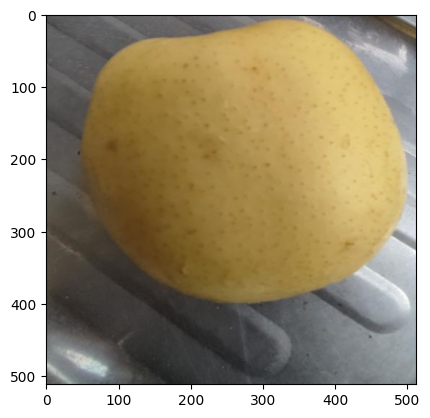

In [132]:
plt.imshow(all_images[10])
plt.show()

In [133]:
np.array(all_images).shape

(205, 512, 512, 3)

In [134]:
resize(all_images[10], (256, 256))

array([[[0.33783473, 0.33783473, 0.33783473],
        [0.33647309, 0.33647309, 0.33647309],
        [0.34172699, 0.34172699, 0.34172699],
        ...,
        [0.64879885, 0.65996801, 0.68801453],
        [0.63368667, 0.64564989, 0.68012642],
        [0.58149589, 0.59677288, 0.63164644]],

       [[0.32368298, 0.32368298, 0.32368298],
        [0.33344874, 0.33344874, 0.33344874],
        [0.33922575, 0.33922575, 0.33922575],
        ...,
        [0.61937261, 0.63112609, 0.65859951],
        [0.64051747, 0.6522934 , 0.68014146],
        [0.64737202, 0.65933524, 0.68720574]],

       [[0.32382303, 0.32382303, 0.32382303],
        [0.33358856, 0.33358856, 0.33358856],
        [0.33936598, 0.33936598, 0.33936598],
        ...,
        [0.62068889, 0.63285068, 0.66008068],
        [0.62527388, 0.63701615, 0.66407004],
        [0.63271446, 0.64408213, 0.67111359]],

       ...,

       [[0.35944167, 0.36728481, 0.36336324],
        [0.35645611, 0.36429924, 0.36037768],
        [0.36922354, 0

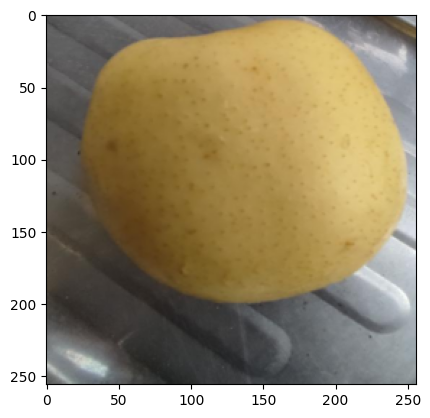

In [135]:
plt.imshow(resize(all_images[10], (256, 256), preserve_range=True).astype(np.uint8))

(array([3.000e+00, 6.000e+00, 1.100e+01, 2.000e+01, 3.400e+01, 7.000e+01,
        9.900e+01, 0.000e+00, 1.370e+02, 2.330e+02, 3.170e+02, 4.330e+02,
        4.770e+02, 5.020e+02, 5.160e+02, 0.000e+00, 5.220e+02, 4.500e+02,
        4.570e+02, 5.630e+02, 6.600e+02, 6.930e+02, 8.060e+02, 0.000e+00,
        8.500e+02, 1.031e+03, 1.117e+03, 1.369e+03, 1.596e+03, 1.835e+03,
        2.007e+03, 0.000e+00, 1.900e+03, 1.779e+03, 1.683e+03, 1.672e+03,
        1.771e+03, 1.637e+03, 0.000e+00, 1.461e+03, 1.348e+03, 1.214e+03,
        1.168e+03, 1.083e+03, 1.051e+03, 9.590e+02, 0.000e+00, 8.720e+02,
        7.920e+02, 8.380e+02, 8.500e+02, 9.250e+02, 9.560e+02, 1.050e+03,
        0.000e+00, 9.320e+02, 9.740e+02, 9.770e+02, 9.890e+02, 1.034e+03,
        1.136e+03, 1.276e+03, 0.000e+00, 1.310e+03, 1.354e+03, 1.764e+03,
        2.030e+03, 2.007e+03, 1.953e+03, 0.000e+00, 2.013e+03, 1.943e+03,
        2.098e+03, 2.035e+03, 2.250e+03, 2.148e+03, 2.129e+03, 0.000e+00,
        1.945e+03, 1.863e+03, 1.593e+0

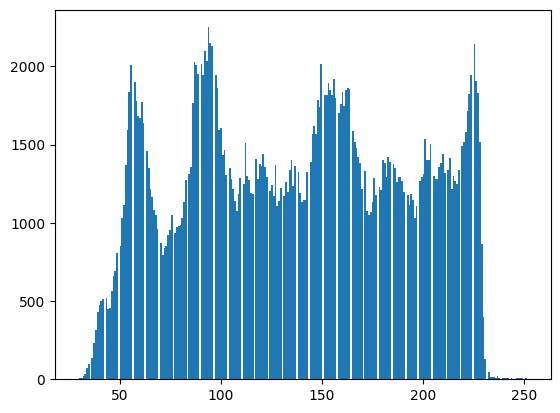

In [136]:
plt.hist(all_images[10][:, :, 0].ravel(), bins=256 )

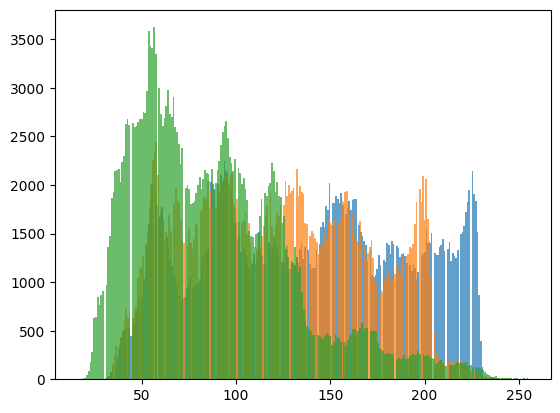

In [137]:
plt.hist(all_images[10][:, :, 0].ravel(), bins=256, alpha = 0.7)
plt.hist(all_images[10][:, :, 1].ravel(), bins=256, alpha = 0.7)
plt.hist(all_images[10][:, :, 2].ravel(), bins=256, alpha = 0.7)
plt.show()

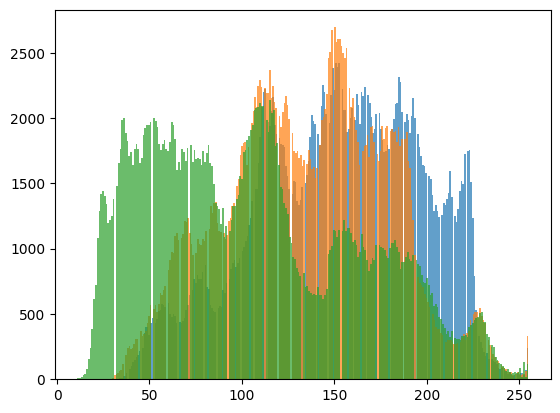

In [138]:
plt.hist(all_images[20][:, :, 0].ravel(), bins=256, alpha = 0.7)
plt.hist(all_images[20][:, :, 1].ravel(), bins=256, alpha = 0.7)
plt.hist(all_images[20][:, :, 2].ravel(), bins=256, alpha = 0.7)
plt.show()

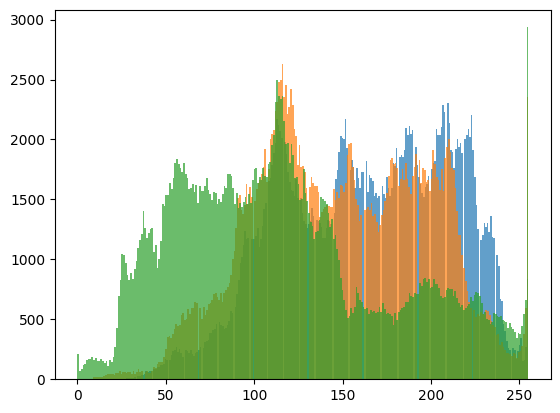

In [139]:
plt.hist(all_images[200][:, :, 0].ravel(), bins=256, alpha = 0.7)
plt.hist(all_images[200][:, :, 1].ravel(), bins=256, alpha = 0.7)
plt.hist(all_images[200][:, :, 2].ravel(), bins=256, alpha = 0.7)
plt.show()

In [140]:
def show_image(image):
    plt.imshow(image)
    plt.hist(image[:, :, 0].ravel(), bins=256, alpha = 0.7)
    plt.hist(image[:, :, 1].ravel(), bins=256, alpha = 0.7)
    plt.hist(image[:, :, 2].ravel(), bins=256, alpha = 0.7)
    plt.show()

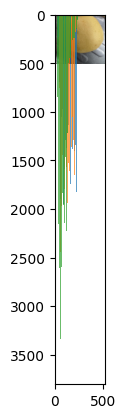

In [141]:
show_image(all_images[10])

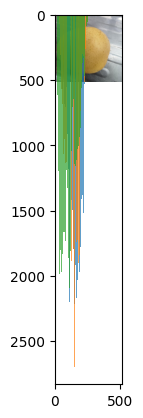

In [142]:
show_image(all_images[20])

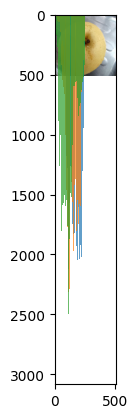

In [143]:
show_image(all_images[200])

In [144]:
rgb2lab(all_images[200])

array([[[55.59468101,  0.39592909, -1.07088067],
        [55.59468101,  0.39592909, -1.07088067],
        [55.20524004,  0.39649812, -1.0723571 ],
        ...,
        [21.52808854,  2.96441989,  3.22163935],
        [21.58161234,  3.04491534,  4.67092307],
        [21.58161234,  3.04491534,  4.67092307]],

       [[55.59468101,  0.39592909, -1.07088067],
        [55.59468101,  0.39592909, -1.07088067],
        [55.20524004,  0.39649812, -1.0723571 ],
        ...,
        [21.52808854,  2.96441989,  3.22163935],
        [21.58161234,  3.04491534,  4.67092307],
        [21.58161234,  3.04491534,  4.67092307]],

       [[53.64209994,  0.39882285, -1.07838493],
        [53.64209994,  0.39882285, -1.07838493],
        [54.03370035,  0.39823422, -1.07685929],
        ...,
        [21.98388574,  2.95309974,  3.21050898],
        [21.98388574,  2.95309974,  3.21050898],
        [21.52808854,  2.96441989,  3.22163935]],

       ...,

       [[36.52764216, -1.46361369, 11.82278534],
        [35

In [145]:
rgb2lab(all_images[200]).shape

(512, 512, 3)

In [146]:
apple_lab = rgb2lab(all_images[200])

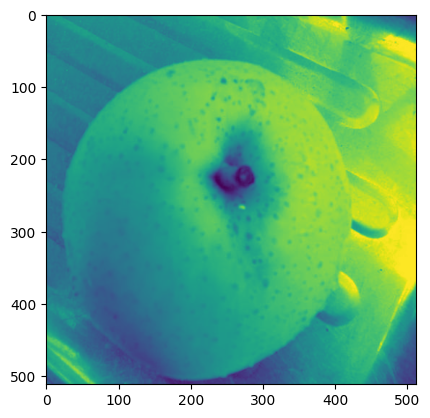

In [147]:
plt.imshow(apple_lab[:, :, 0])
plt.show()

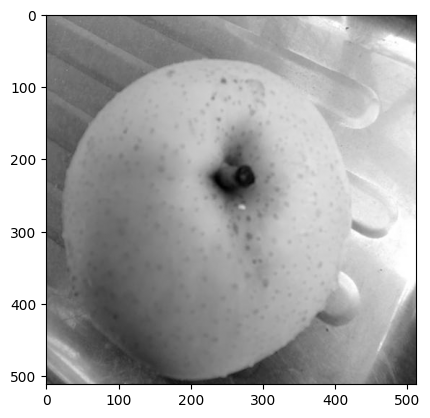

In [148]:
plt.imshow(apple_lab[:, :, 0], cmap='gray')
plt.show()

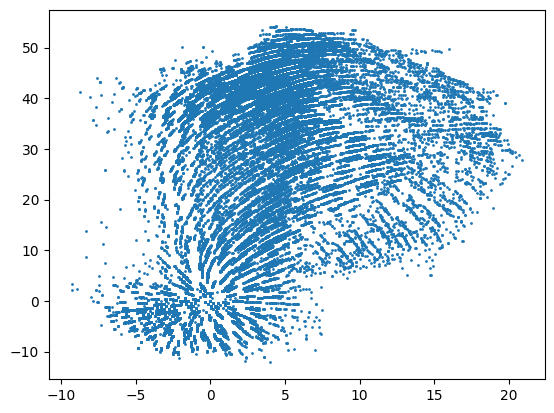

In [149]:
plt.scatter(apple_lab[:, :, 1], apple_lab[:, :, 2], s=1)
plt.show()

In [150]:
apple2_lab = rgb2lab(all_images[142])

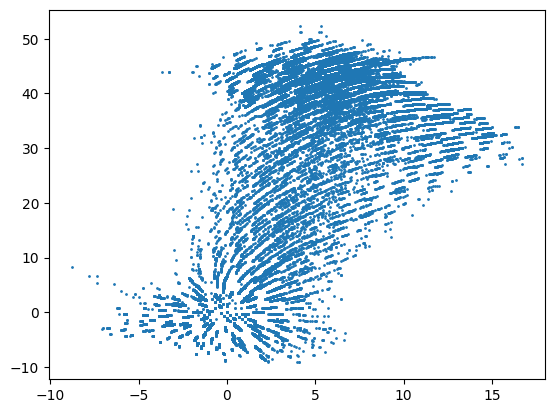

In [151]:
plt.scatter(apple2_lab[:, :, 1], apple2_lab[:, :, 2], s=1)
plt.show()

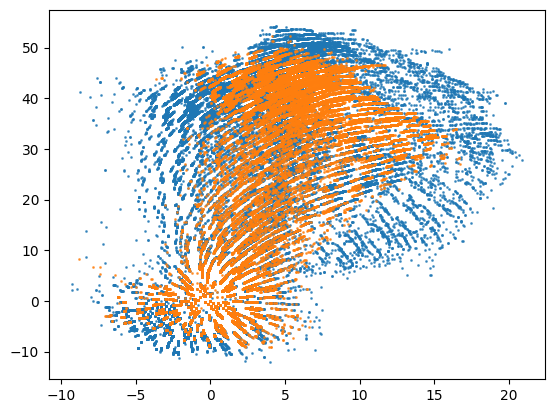

In [152]:
plt.scatter(apple_lab[:, :, 1], apple_lab[:, :, 2], s=1, alpha=0.7)
plt.scatter(apple2_lab[:, :, 1], apple2_lab[:, :, 2], s=1, alpha=0.7)
plt.show()

### Problem 2. Convolutions
Play around with some filters on a few chosen images. Remember, the main idea is to recreate the masks as closely as possible. You don't need the background and you should not use it for measuring; so you'll have to segment it out.

How can you use edge / corner detection? Does blurring or sharpening help? Some ideas to try:
* Sobel, Laplacian
* Gaussian blur (with varying radii)
* Sharpening / unsharp mask

What if nothing really helps? Can we devise a series of operations to improve the quality of our operators?

In [153]:
apple_gray = rgb2gray(apple_lab)
threshold_result = threshold_otsu(apple_gray)

In [154]:
(apple_gray * 255).astype(np.uint8)

array([[249, 249, 228, ..., 230,  18,  18],
       [249, 249, 228, ..., 230,  18,  18],
       [143, 143, 164, ..., 253, 253, 230],
       ...,
       [137,  72, 218, ..., 136, 161, 161],
       [ 50, 239, 150, ...,  74,  74,  74],
       [ 50,   5, 195, ..., 100, 100,  74]], shape=(512, 512), dtype=uint8)

In [155]:
apple_mask = apple_gray.copy()
apple_mask[apple_mask <= threshold_result] = 0
apple_mask[apple_mask > threshold_result] = 1

In [156]:
apple_mask

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(512, 512))

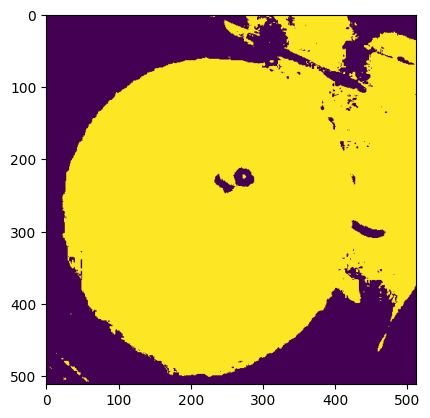

In [157]:
plt.imshow(apple_mask)

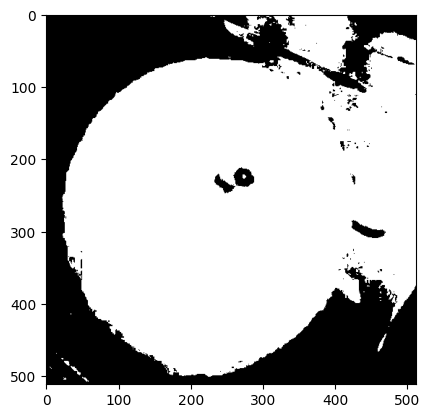

In [158]:
plt.imshow(apple_mask, cmap="grey")
plt.show()

In [159]:
apple_mask = apple_gray.copy()
apple_mask[apple_mask <= threshold_result] = 0
apple_mask[apple_mask > threshold_result] = 1
apple_mask = 1 - apple_mask

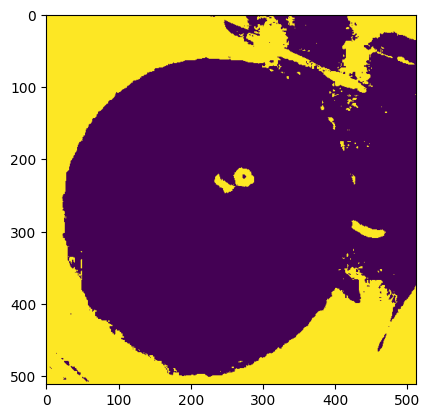

In [160]:
plt.imshow(apple_mask)

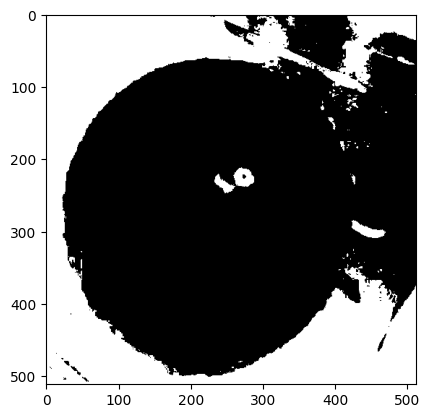

In [161]:
plt.imshow(apple_mask, cmap="grey")
plt.show()

In [162]:
sobel(apple_lab)

array([[[31.86901428, 32.71587729,  0.84686301],
        [31.81316769, 32.65992789,  0.84715843],
        [31.65926076, 32.50598123,  0.84797254],
        ...,
        [10.7308226 , 10.38706822,  0.72827611],
        [10.70611657,  9.96774491,  0.97874251],
        [10.702167  ,  9.763391  ,  0.938776  ]],

       [[31.59806837, 32.43635619,  0.84836856],
        [31.56797327, 32.40821336,  0.84851284],
        [31.50679336, 32.35185419,  0.84879974],
        ...,
        [10.83598952, 10.53689329,  0.5921607 ],
        [10.76024797, 10.16871896,  0.90417972],
        [10.72303664,  9.98424577,  0.97980341]],

       [[30.73766795, 31.5403224 ,  0.85327606],
        [30.77314169, 31.5820524 ,  0.85303428],
        [30.89903553, 31.72172287,  0.85224146],
        ...,
        [11.04257367, 10.83876678,  0.30906787],
        [10.95700942, 10.65399689,  0.59738725],
        [10.88844076, 10.53674497,  0.73815017]],

       ...,

       [[21.60200963, 13.89629286,  7.64069231],
        [21

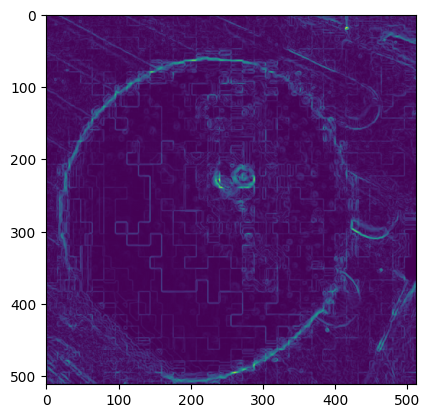

In [163]:
plt.imshow(sobel(apple_gray))

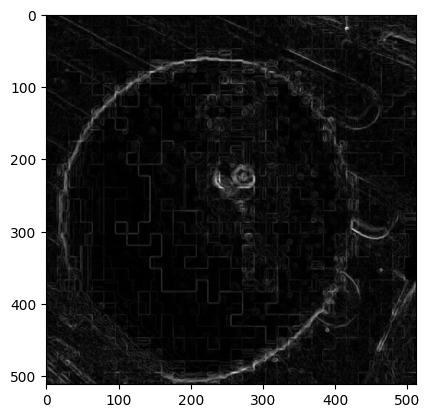

In [164]:
plt.imshow(sobel(apple_gray), cmap="grey")
plt.show()

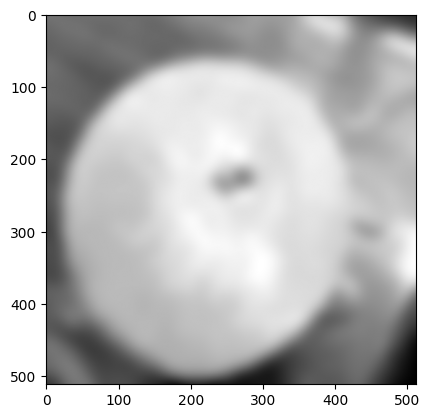

In [165]:
plt.imshow(gaussian(apple_gray, sigma = 10), cmap="grey")
plt.show()

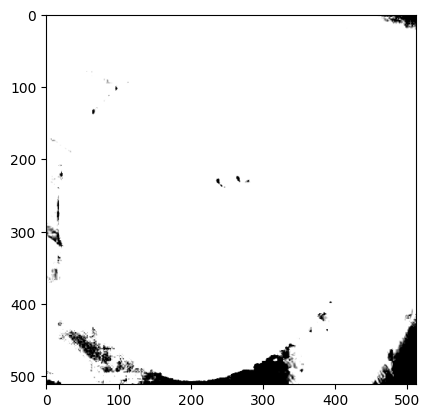

In [166]:
plt.imshow(unsharp_mask(apple_gray, radius=1000), cmap="grey")
plt.show()

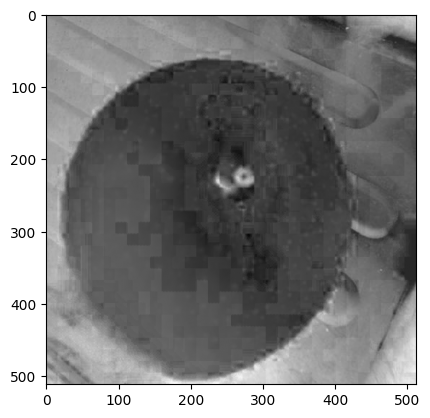

In [167]:
plt.imshow(unsharp_mask(apple_gray, radius=1) - apple_gray, cmap="grey")
plt.show()

### Problem 3. Image enhancements
In the last problem, you likely saw that convolutions - on their own - aren't enough. Try enhancing the images. Keep in mind that there's a difference between what looks good to you, and what is useful for a model.

Some ideas you might want to try:
* Contrast stretching
* Histogram equalization (CLAHE in particular) or other contrast-enhancing methods
* Conversion to Lab / HSL - for better / easier work with grayscale images
* \* Optional: Does grayscale really work here? I would use it for better masking / foreground segmentation, but I would definitely use the colors if I need to classify images afterwards.

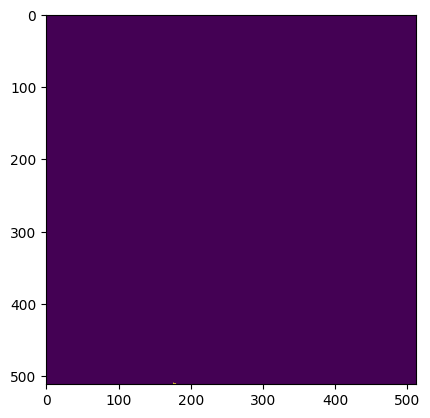

In [168]:
result = apple_gray.copy()
apple_blurred = gaussian(apple_gray, sigma=2)
apple_unsharp = unsharp_mask(apple_blurred, radius=100)

th = threshold_otsu(apple_unsharp)
result[result < th] = 0
result[result >= th] = 1
result = 1 - result
plt.imshow(result)

In [169]:
footprint_rectangle((3, 3))

array([[1, 1, 1],
       [1, 1, 1],
       [1, 1, 1]], dtype=uint8)

### Problem 4. Segment the images (finally)
Try several enhancements and see if they improve (or worsen) the quality of the convolution features.

Segment fruit from background. You may initially try several images only for simplicity. Try to pick a representative sample.

You can use convolutions, HOG, morphology... whatever you see fit. The goal is to create a binary mask where `1` is "fruit" and `0` is background.

C:\Users\PC\AppData\Local\Temp\ipykernel_5204\3588868496.py:3: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  closing_result = binary_closing(result, footprint_rectangle((size, size)))


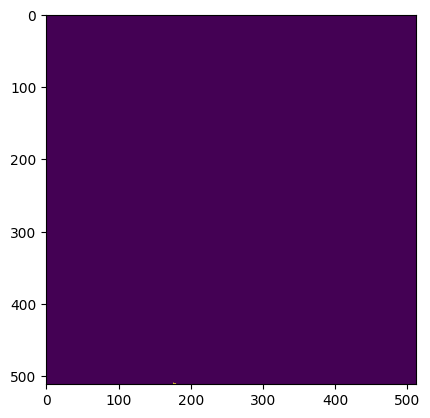

In [170]:
size = 20

closing_result = binary_closing(result, footprint_rectangle((size, size)))
plt.imshow(closing_result)

C:\Users\PC\AppData\Local\Temp\ipykernel_5204\1325586440.py:3: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  closing_result = binary_closing(result, diamond(size))


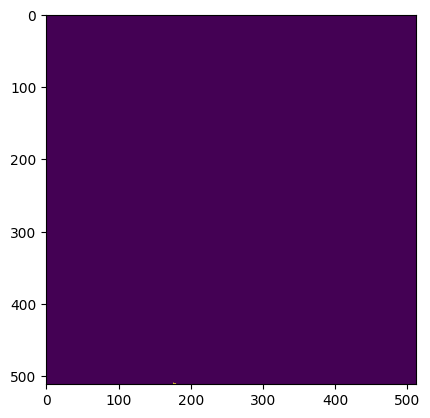

In [171]:
size = 20

closing_result = binary_closing(result, diamond(size))
plt.imshow(closing_result)

C:\Users\PC\AppData\Local\Temp\ipykernel_5204\2082070870.py:3: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  closing_result = binary_closing(result, disk(size))


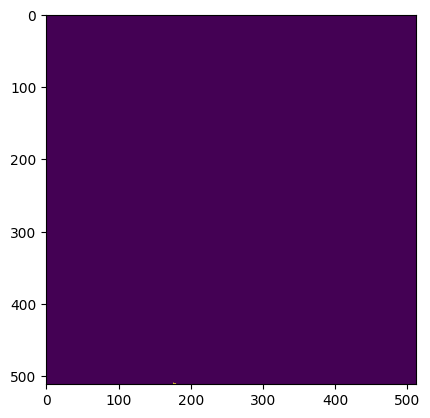

In [172]:
size = 20

closing_result = binary_closing(result, disk(size))
plt.imshow(closing_result)

C:\Users\PC\AppData\Local\Temp\ipykernel_5204\1643294011.py:2: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  opening_result = binary_opening(result, disk(size))
C:\Users\PC\AppData\Local\Temp\ipykernel_5204\1643294011.py:3: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  closing_result = binary_closing(result, disk(size))


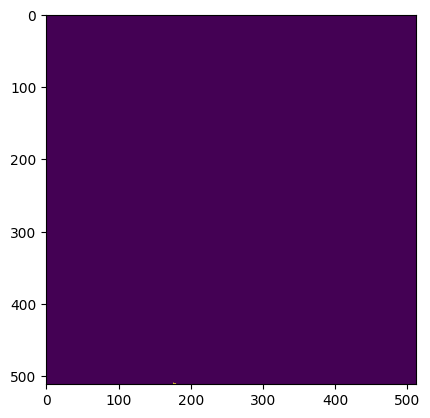

In [173]:
size = 20
opening_result = binary_opening(result, disk(size))
closing_result = binary_closing(result, disk(size))
plt.imshow(closing_result)

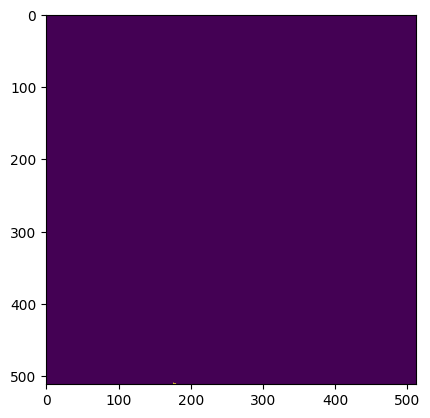

In [174]:
plt.imshow(closing_result.astype(int)* 255)
plt.show()

In [175]:
image_paths

['1.jpg',
 '10.jpg',
 '11.jpg',
 '12.jpg',
 '13.jpg',
 '14.jpg',
 '15.jpg',
 '16.jpg',
 '17.jpg',
 '18.jpg',
 '19.jpg',
 '2.jpg',
 '20.jpg',
 '21.jpg',
 '22.jpg',
 '23.jpg',
 '24.jpg',
 '25.jpg',
 '26.jpg',
 '27.jpg',
 '28.jpg',
 '29.jpg',
 '3.jpg',
 '30.jpg',
 '31.jpg',
 '32.jpg',
 '33.jpg',
 '34.jpg',
 '35.jpg',
 '36.jpg',
 '37.jpg',
 '38.jpg',
 '39.jpg',
 '4.jpg',
 '40.jpg',
 '41.jpg',
 '5.jpg',
 '6.jpg',
 '7.jpg',
 '8.jpg',
 '9.jpg']

In [176]:
len(image_paths)

41

In [177]:
image_paths[25]

'32.jpg'

In [178]:
plt.imshow(imread(image_paths[2]))
plt.show()

FileNotFoundError: No such file: 'c:\Обучения\Data Science\Working with Images\11.jpg'

In [ ]:
mask_path = image_paths[25].replace("Images", "Masks").replace(".jpg", ".png")
imread(mask_path)

FileNotFoundError: No such file: 'c:\Обучения\Data Science\Working with Images\32.png'

In [ ]:
plt.imshow(imread(mask_path))
plt.show()

FileNotFoundError: No such file: 'c:\Обучения\Data Science\Working with Images\32.png'

In [ ]:
original_mask = imread(mask_path)
set(original_mask.ravel())

FileNotFoundError: No such file: 'c:\Обучения\Data Science\Working with Images\32.png'

### Problem 5. Evaluate your masks
In this dataset, you're given a "ground truth" of masks. How good is your mask, relative to the ground truth? How would you measure that?

There are several approaches to this problem. I suggest you treat this as a classification task. Your mask is your hypothesis; the masks in the dataset are the ground truth. Think about true positives, true negatives, etc.; and provide a confusion matrix.

You may also look at `IoU` (intersection over union) to measure the quality of the masks you generated.

In [ ]:
closing_result = closing_result.astype(int)
closing_result

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(512, 512))

In [ ]:
original_mask = imread(mask_path)
mask = original_mask.copy()
mask[mask <= 128] = 1
mask[mask > 128] = 0

FileNotFoundError: No such file: 'c:\Обучения\Data Science\Working with Images\32.png'

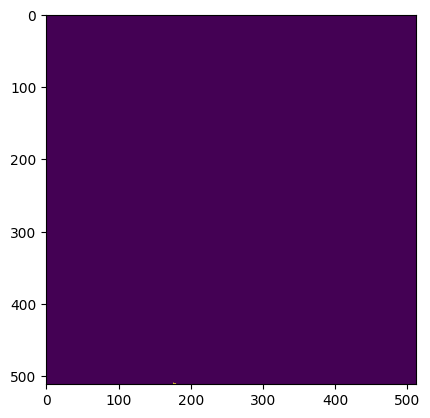

In [ ]:
plt.imshow(closing_result == 1)

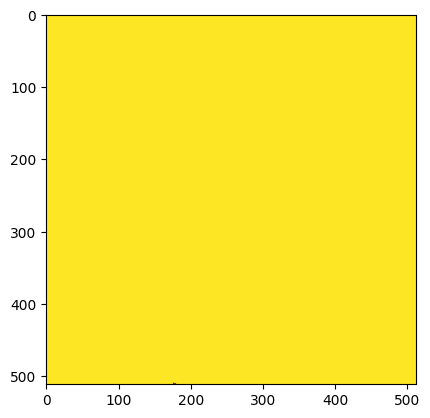

In [ ]:
plt.imshow(closing_result == 0)

In [ ]:
classification_report(closing_result.ravel(), mask.ravel())

NameError: name 'mask' is not defined

### Problem 6. Similar images - removal?
Devise a way to filter out images that are too similar to one another. Do we need them? Is it safe to remove them in order to reduce the dataset size?abs

You'll need to find a good way to compare images. I suggest using features and distances, not raw pixels. Even if a few pixels are off (or if there's a bit of noise), two images may still be considered the same.

In [ ]:
import cv2

from skimage.metrics import structural_similarity as ssim

def are_images_similar(image1_path, image2_path, threshold=0.95):
    """
    Checks if two images are similar using Structural Similarity Index (SSIM).
    """
    img1 = cv2.imread(image1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(image2_path, cv2.IMREAD_GRAYSCALE)
    
    # Ensure images have the same size before comparing
    if img1 is None or img2 is None:
        return False
        
    if img1.shape != img2.shape:
        img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))
        
    score, _ = ssim(img1, img2, full=True)
    return score > threshold

# Example usage (commented out to avoid heavy computation across the whole dataset)
#
# folder = 'data/Apple_Gala/Images'
# images = os.listdir(folder)
# images = [os.path.join(folder, img) for img in images if img.endswith('.jpg') or img.endswith('.png')]
#
# similar_pairs = []
# for i in range(len(images)):
#     for j in range(i + 1, len(images)):
#         if are_images_similar(images[i], images[j], 0.98):
#             similar_pairs.append((images[i], images[j]))
#             print(f"Similar: {images[i]} and {images[j]}")
#
# print(f"Found {len(similar_pairs)} pairs of highly similar images.")

In [ ]:
# Write your code here

### Problem 7. Measurements
Now that you have a - hopefully - well-masked fruits, perform measurements on the masks. Try to provide statistics which will differentiate between classes. I mean, the statistics within the same group (e.g., apple) should be similar, but across groups should be different enough.

Some things you might want to measure include: area, perimeter, bounding box size and aspect ratio, orientation. Don't forget that there are color images "inside" the masks: so you could measure contrast, color variance, mean / median color, dominant colors or color discretization (and you can perform clustering on those too).

In [ ]:
hog(apple_gray)

array([0.05319151, 0.00620571, 0.01000293, ..., 0.15902285, 0.05121075,
       0.        ], shape=(311364,))

In [ ]:
hog(apple_gray, pixels_per_cell=(20, 20), cells_per_block=(1, 1)).shape

(5625,)

In [ ]:
hog(apple_gray, pixels_per_cell=(35, 35), cells_per_block=(3, 3)).shape

(11664,)

In [ ]:
hog_result = hog(apple_gray, pixels_per_cell=(35, 35), cells_per_block=(3, 3)).shape

In [ ]:
all_hog_results = [hog(image, channel_axis=2) for image in all_images[:3]]

In [ ]:
all_hog_results[0].shape

(311364,)

In [ ]:
all_hog_results = [hog(apple_gray, pixels_per_cell=(35, 35), cells_per_block=(3, 3), channel_axis= None) for image in all_images]

In [ ]:
all_hog_results[0].shape    

(11664,)

In [ ]:
len(all_hog_results)

205

In [ ]:
all_hog_results = np.array(all_hog_results)

In [ ]:
all_hog_results

array([[0.1365616 , 0.05928781, 0.08381964, ..., 0.06622388, 0.08312492,
        0.1580574 ],
       [0.1365616 , 0.05928781, 0.08381964, ..., 0.06622388, 0.08312492,
        0.1580574 ],
       [0.1365616 , 0.05928781, 0.08381964, ..., 0.06622388, 0.08312492,
        0.1580574 ],
       ...,
       [0.1365616 , 0.05928781, 0.08381964, ..., 0.06622388, 0.08312492,
        0.1580574 ],
       [0.1365616 , 0.05928781, 0.08381964, ..., 0.06622388, 0.08312492,
        0.1580574 ],
       [0.1365616 , 0.05928781, 0.08381964, ..., 0.06622388, 0.08312492,
        0.1580574 ]], shape=(205, 11664))

In [ ]:
all_hog_results @ all_hog_results.T

array([[143.99999998, 143.99999998, 143.99999998, ..., 143.99999998,
        143.99999998, 143.99999998],
       [143.99999998, 143.99999998, 143.99999998, ..., 143.99999998,
        143.99999998, 143.99999998],
       [143.99999998, 143.99999998, 143.99999998, ..., 143.99999998,
        143.99999998, 143.99999998],
       ...,
       [143.99999998, 143.99999998, 143.99999998, ..., 143.99999998,
        143.99999998, 143.99999998],
       [143.99999998, 143.99999998, 143.99999998, ..., 143.99999998,
        143.99999998, 143.99999998],
       [143.99999998, 143.99999998, 143.99999998, ..., 143.99999998,
        143.99999998, 143.99999998]], shape=(205, 205))

In [ ]:
covariance_matrix = all_hog_results @ all_hog_results.T

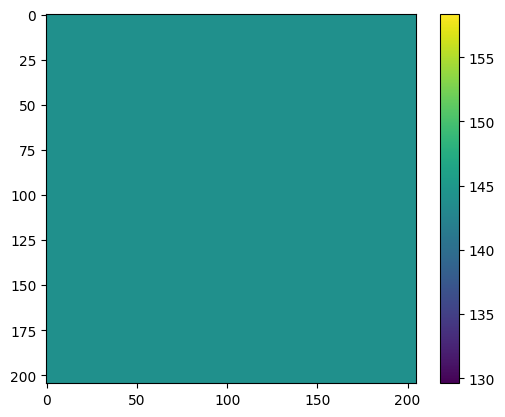

In [ ]:
plt.imshow(covariance_matrix)
plt.colorbar()
plt.show()

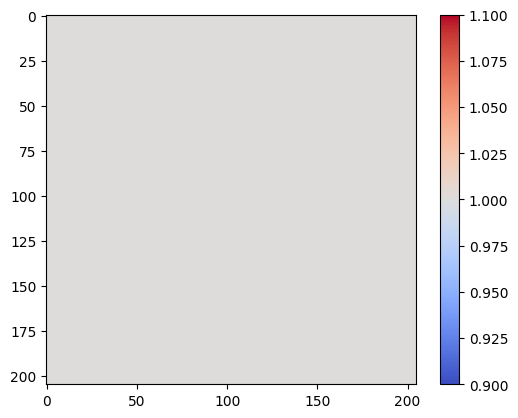

In [ ]:
plt.imshow(np.corrcoef(all_hog_results), cmap='coolwarm')
plt.colorbar()  
plt.show()  

In [ ]:
np.linalg.norm(all_hog_results, axis=1).shape

(205,)

In [ ]:
np.linalg.norm(all_hog_results, axis=1)

array([12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12.,
       12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12.,
       12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12.,
       12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12.,
       12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12.,
       12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12.,
       12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12.,
       12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12.,
       12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12.,
       12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12.,
       12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12.,
       12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12.,
       12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12.,
       12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12

In [ ]:
corr_coef = np.corrcoef(all_hog_results)

In [ ]:
corr_coef

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], shape=(205, 205))

In [179]:
apple_gray[mask == 0] = 0

NameError: name 'mask' is not defined

### Problem 8. * U-Net
This is going to be quite a stretch from the previous tasks. You've been warned!

Design a neural network which will generate the mask when given the image. You're on your own here, I'm just going to provide a few keywords to make the task more managable: the U-net architecture is a common, easy one to do this task; you may need data augmentation; try using pretrained models and transfer learning.

In [ ]:
# Write your code here